In [42]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs

from unseen import fileio
from unseen import array_handling

In [2]:
infile = '/g/data/xv83/unseen-projects/outputs/wcrp-txx/data/tasmax-june-july_NorCPM1-dcppA-hindcast_196010-201810_annual_north-america.nc'

In [15]:
ds = fileio.open_dataset(infile)
ds = ds.compute()
ds = array_handling.reindex_forecast(ds)

In [34]:
ds_baseline = ds.sel(time=slice('1991-01-01', '2020-12-31'))

In [39]:
ds_clim = ds_baseline.mean(dim=['time', 'init_date', 'ensemble'])

In [40]:
ds_clim

<xarray.Dataset> Size: 6kB
Dimensions:  (lat: 27, lon: 53)
Coordinates:
  * lon      (lon) float64 424B 175.0 177.5 180.0 182.5 ... 300.0 302.5 305.0
  * lat      (lat) float64 216B 25.58 27.47 29.37 31.26 ... 71.05 72.95 74.84
Data variables:
    tasmax   (lat, lon) float32 6kB 22.43 22.31 22.2 ... 0.05457 -0.1537 -1.967

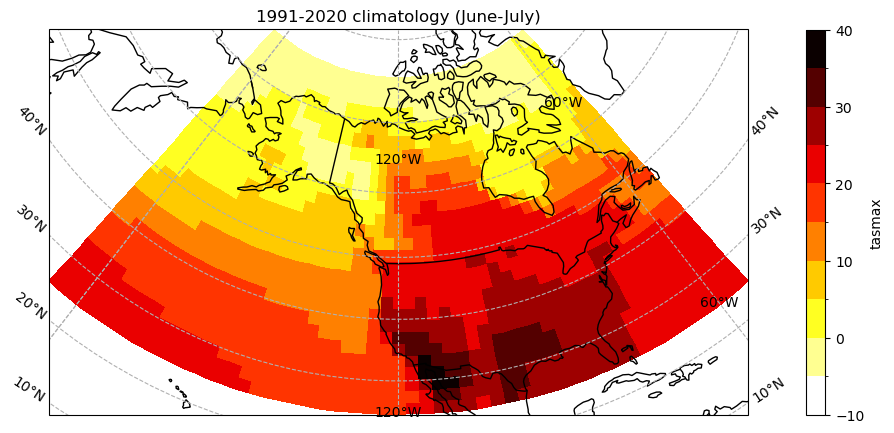

In [51]:
map_proj = ccrs.LambertConformal(
    central_longitude=240,
    central_latitude=50,
)

fig = plt.figure(figsize=[15, 5])
ax = fig.add_subplot(111, projection=map_proj)

ds_clim['tasmax'].plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='hot_r',
    levels=np.arange(-10, 45, 5),
#    extend='both',
    #    cbar_kwargs={"label": label},
)
#lines = da_psl.isel(time=4).plot.contour(
#    ax=ax,
#    transform=ccrs.PlateCarree(),
#    levels=np.arange(900, 1100, 3),
#    colors=["0.3"]
#)
#ax.clabel(lines, colors=["0.3"], manual=False, inline=True)
    
ax.coastlines()
ax.add_feature(cartopy.feature.BORDERS)
ax.gridlines(linestyle="--", draw_labels=True)

plt.title('1991-2020 climatology (June-July)')
plt.show()